In [ ]:
# Passage Re-ranking with BERT

### Reimplementation of Nogueira & Cho

This notebook implements a BERT-based passage re-ranking pipeline inspired by:

> Nogueira, R., & Cho, K. (2019). Passage Re-ranking with BERT.

The goal is to reproduce the core query–passage re-ranking approach while using a resource-efficient implementation suitable for limited GPU environments.

---

### Main Components

- MS MARCO v1.1
- Query–passage pair construction
- Lazy tokenization
- BERT sequence classification
- AdamW optimization
- Gradient accumulation
- MRR@10 evaluation
- Training and validation monitoring
- Comparison with the original paper

In [ ]:
## Introduction

Passage retrieval systems typically retrieve a set of candidate passages using a fast retrieval method such as BM25.

A neural re-ranker can then evaluate the relevance of each query–passage pair and reorder the retrieved candidates.

The core idea explored in this project is:

Query + Passage
→ BERT
→ Relevance Score
→ Re-ranked Passages

This notebook focuses on implementing and evaluating the BERT re-ranking component.

In [ ]:
## Environment Setup

The implementation is designed to run in a constrained GPU environment.

To reduce memory consumption, the implementation uses:

- Lazy tokenization
- PyTorch Dataset/DataLoader
- Micro-batches
- Gradient accumulation

In [ ]:
# #Install and import libraries

# !pip install datasets
# !pip install transformers
# !pip install evaluate
# !pip install torch

In [ ]:
## Imports and Reproducibility

The experiment uses a fixed random seed to improve reproducibility.


In [ ]:


import os
import math
import json
import random
from collections import defaultdict

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer,
    BertConfig,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [ ]:
## Experiment Configuration

The following configuration defines the main experimental parameters used throughout the notebook.

In [ ]:


MODEL_NAME = "bert-base-uncased"  # was bert-large-uncased; switched because Colab's GPU can't fit large at seq_len=512

MAX_LENGTH = 512
QUERY_MAX_TOKENS = 64
DROPOUT = 0.1

# ==========================================
# Training Configuration
# ==========================================
# ------------------------------------------
# Original Paper Configuration
# ------------------------------------------
PAPER_MAX_STEPS = 100_000
PAPER_BATCH_SIZE = 128
PAPER_LEARNING_RATE = 3e-6
PAPER_WARMUP_STEPS = 10_000
PAPER_WEIGHT_DECAY = 0.01

# ------------------------------------------
# Our Colab Configuration
# ------------------------------------------
# Reduced training budget because of Colab Free
MAX_OPTIMIZER_STEPS = 1_000
# Micro-batch size that fits in GPU memory
MICRO_BATCH_SIZE = 4
# Gradient accumulation
GRAD_ACCUMULATION_STEPS = 32
# Effective batch size (matches the paper's 128)
EFFECTIVE_BATCH_SIZE = MICRO_BATCH_SIZE * GRAD_ACCUMULATION_STEPS
# Keep the paper's learning rate
LEARNING_RATE = 3e-6
# Reduced warmup proportionally for the shorter run
WARMUP_STEPS = 100
# Keep the paper's weight decay
WEIGHT_DECAY = 0.01

# NOTE: no EVAL_EVERY_STEPS anymore. The new training loop below only runs
# validation once, at the end, instead of periodically. That's fine for a
# 1,000-step Colab run, but it means we no longer track/keep a "best"
# checkpoint by validation MRR — the final step's weights are what you get,
# even if an earlier step happened to score higher. Say so in the paper if
# you keep it this way.

print("===== Paper Configuration =====")
print(f"Max Steps       : {PAPER_MAX_STEPS}")
print(f"Batch Size      : {PAPER_BATCH_SIZE}")
print(f"Learning Rate   : {PAPER_LEARNING_RATE}")
print(f"Warmup Steps    : {PAPER_WARMUP_STEPS}")
print(f"Weight Decay    : {PAPER_WEIGHT_DECAY}")

print("\n===== Our Colab Configuration =====")
print(f"Max Steps       : {MAX_OPTIMIZER_STEPS}")
print(f"Micro Batch     : {MICRO_BATCH_SIZE}")
print(f"Accumulation    : {GRAD_ACCUMULATION_STEPS}")
print(f"Effective Batch : {EFFECTIVE_BATCH_SIZE}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Warmup Steps    : {WARMUP_STEPS}")
print(f"Weight Decay    : {WEIGHT_DECAY}")

===== Paper Configuration =====
Max Steps       : 100000
Batch Size      : 128
Learning Rate   : 3e-06
Warmup Steps    : 10000
Weight Decay    : 0.01

===== Our Colab Configuration =====
Max Steps       : 1000
Micro Batch     : 4
Accumulation    : 32
Effective Batch : 128
Learning Rate   : 3e-06
Warmup Steps    : 100
Weight Decay    : 0.01


In [ ]:
## Dataset

This implementation uses MS MARCO version 1.1 through the Hugging Face Datasets library.

Each query contains candidate passages together with relevance labels.

In [ ]:


#load dataset
dataset = load_dataset("microsoft/ms_marco", "v1.1")
print(dataset)

DatasetDict({
    validation: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 10047
    })
    train: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 82326
    })
    test: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 9650
    })
})


In [ ]:


#Incpect one sample
sample = dataset["train"][0]

print("Sample keys:", sample.keys())
print("Passage keys:", sample["passages"].keys())
print("\nQuery:\n", sample["query"])
print("\nLabels:\n", sample["passages"]["is_selected"])

Sample keys: dict_keys(['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'])
Passage keys: dict_keys(['is_selected', 'passage_text', 'url'])

Query:
 what is rba

Labels:
 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


In [ ]:
## Query–Passage Pair Construction

BERT does not receive the original MS MARCO structure directly.

Instead, each candidate passage is converted into a query–passage pair:

(query, passage, label)

For example:

Query
+
Passage A
→ Label 1

Query
+
Passage B
→ Label 0

The `query_id` is preserved because it is required later to reconstruct the ranking for MRR@10 evaluation.

In [ ]:


# create query passage pairs
def create_pairs(split_dataset):
    """
    Convert one split of MS MARCO into (query, passage, label) pairs.
    Keeps query_id for ranking-based evaluation.
    """
    pairs = []

    for sample in split_dataset:
        query = sample["query"]
        query_id = str(sample["query_id"])

        passages = sample["passages"]["passage_text"]
        labels = sample["passages"]["is_selected"]

        for passage_text, label in zip(passages, labels):
            pairs.append({
                "query_id": query_id,
                "query": query,
                "passage": passage_text,
                "label": int(label),
            })

    return pairs

In [ ]:
### Build Query–Passage Pairs

The pair construction is applied to the complete training and validation splits rather than only to a sample.

In [ ]:


#Build train /validation pairs
train_pairs = create_pairs(dataset["train"])
validation_pairs = create_pairs(dataset["validation"])

print("Train pairs:", len(train_pairs))
print("Validation pairs:", len(validation_pairs))

Train pairs: 676193
Validation pairs: 82360


In [ ]:


#Check class distubution
train_pos = sum(pair["label"] for pair in train_pairs)
train_neg = len(train_pairs) - train_pos

val_pos = sum(pair["label"] for pair in validation_pairs)
val_neg = len(validation_pairs) - val_pos

print(f"Train Positive:   {train_pos}")
print(f"Train Negative:   {train_neg}")
print(f"Validation Positive: {val_pos}")
print(f"Validation Negative: {val_neg}")

Train Positive:   88523
Train Negative:   587670
Validation Positive: 10783
Validation Negative: 71577


In [ ]:
##  Tokenization

The tokenizer converts the query–passage text into BERT-compatible token IDs.

Tokenization is performed lazily inside the PyTorch Dataset rather than storing all tokenized samples in memory.

This reduces memory consumption and allows the implementation to process large datasets under constrained hardware resources.

In [ ]:


#Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print(tokenizer)

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [ ]:


#Custom dataset wiyyh lazy Tokenizer
class MSMARCODataset(Dataset):
    def __init__(self, pairs, tokenizer, max_length=512, query_max_tokens=64):
        self.pairs = pairs
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.query_max_tokens = query_max_tokens

        self.cls_id = tokenizer.cls_token_id
        self.sep_id = tokenizer.sep_token_id
        self.pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        # Query truncation to paper's 64-token limit
        query_ids = self.tokenizer.encode(
            pair["query"],
            add_special_tokens=False,
            truncation=True,
            max_length=self.query_max_tokens,
        )

        # Passage budget after [CLS], [SEP], [SEP]
        passage_budget = self.max_length - len(query_ids) - 3
        passage_budget = max(1, passage_budget)

        passage_ids = self.tokenizer.encode(
            pair["passage"],
            add_special_tokens=False,
            truncation=True,
            max_length=passage_budget,
        )

        input_ids = [self.cls_id] + query_ids + [self.sep_id] + passage_ids + [self.sep_id]
        token_type_ids = [0] * (len(query_ids) + 2) + [1] * (len(passage_ids) + 1)
        attention_mask = [1] * len(input_ids)

        pad_len = self.max_length - len(input_ids)
        if pad_len > 0:
            input_ids += [self.pad_id] * pad_len
            attention_mask += [0] * pad_len
            token_type_ids += [0] * pad_len
        else:
            input_ids = input_ids[:self.max_length]
            attention_mask = attention_mask[:self.max_length]
            token_type_ids = token_type_ids[:self.max_length]

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long),
            "labels": torch.tensor(pair["label"], dtype=torch.long),
            "query_id": pair["query_id"],
        }

In [ ]:
## PyTorch Dataset

The custom Dataset converts each query–passage pair into:

- `input_ids`
- `attention_mask`
- `token_type_ids`
- `labels`

The query is limited to 64 tokens and the complete sequence is limited to 512 tokens.

In [ ]:


#Build pythorch dataset
train_dataset = MSMARCODataset(
    train_pairs,
    tokenizer,
    max_length=MAX_LENGTH,
    query_max_tokens=QUERY_MAX_TOKENS,
)

validation_dataset = MSMARCODataset(
    validation_pairs,
    tokenizer,
    max_length=MAX_LENGTH,
    query_max_tokens=QUERY_MAX_TOKENS,
)

In [ ]:
## DataLoader

A micro-batch is used to fit the model within available GPU memory.

Gradient accumulation is then used to obtain an effective batch size of 128.

In [ ]:


#Data loader
pin_memory = torch.cuda.is_available()

# Renamed train_loader/validation_loader -> *_dataloader to match the
# training loop your friend sent (it references train_dataloader) — the
# original names would have raised a NameError.
train_dataloader = DataLoader(
    train_dataset,
    batch_size=MICRO_BATCH_SIZE,
    shuffle=True,
    pin_memory=pin_memory,
)

validation_dataloader = DataLoader(
    validation_dataset,
    batch_size=MICRO_BATCH_SIZE,
    shuffle=False,
    pin_memory=pin_memory,
)

In [ ]:
## BERT Re-ranker

The query and passage are represented as a single BERT input.

BERT produces two classification logits:

- Non-relevant
- Relevant

The relevance probability is later used as the ranking score.

In [ ]:


#Load BERT for sequnce classification
config = BertConfig.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=DROPOUT,
    attention_probs_dropout_prob=DROPOUT,
)

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


cuda


In [ ]:
## Training Configuration

The optimizer and scheduler are configured using the selected experimental parameters.

AdamW is used for optimization, while a linear learning-rate schedule with warmup is used for training.

In [ ]:


# ==========================================
# Optimizer
# ==========================================
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=MAX_OPTIMIZER_STEPS,
)

In [ ]:
##MRR@10

Mean Reciprocal Rank at 10 is used as the primary ranking metric.

For each query:

1. Candidate passages are scored by BERT.
2. Passages are sorted by relevance score.
3. The rank of the first relevant passage is identified.
4. Reciprocal rank is calculated as `1 / rank`.
5. The reciprocal ranks are averaged across queries.

Only the top 10 ranked passages contribute to MRR@10.

In [ ]:


#MRR@10
def compute_mrr_at_10(model, dataloader, device):
    model.eval()
    grouped = defaultdict(list)

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating MRR@10"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].cpu().tolist()
            query_ids = batch["query_id"]

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            )

            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().tolist()

            for qid, score, label in zip(query_ids, probs, labels):
                grouped[str(qid)].append((score, int(label)))

    reciprocal_ranks = []
    for qid, items in grouped.items():
        ranked = sorted(items, key=lambda x: x[0], reverse=True)[:10]

        rr = 0.0
        for rank, (_, label) in enumerate(ranked, start=1):
            if label == 1:
                rr = 1.0 / rank
                break

        reciprocal_ranks.append(rr)

    return float(np.mean(reciprocal_ranks)) if reciprocal_ranks else 0.0

In [ ]:
## Training

The training process follows:

Batch
→ Forward Pass
→ Loss
→ Backpropagation
→ Gradient Accumulation
→ AdamW Update
→ Learning Rate Scheduler

In [ ]:


# ==========================================
# Training
# ==========================================
import time

model.train()
global_step = 0
micro_step = 0
train_loss_history = []

# Reset so the "Peak GPU Memory" number in the dashboard cell later actually
# reflects this training run, not whatever ran earlier in the session.
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()
optimizer.zero_grad()

while global_step < MAX_OPTIMIZER_STEPS:
    for batch in train_dataloader:
        # -----------------------------
        # Move batch to GPU
        # -----------------------------
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels = batch["labels"].to(device)

        # -----------------------------
        # Forward Pass
        # -----------------------------
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels,
        )
        loss = outputs.loss

        # Save the un-scaled loss for plotting (this is the per-micro-batch
        # loss, so the curve will look noisier than an epoch-averaged one —
        # that's expected, not a bug).
        train_loss_history.append(loss.item())

        # -----------------------------
        # Gradient Accumulation
        # -----------------------------
        loss = loss / GRAD_ACCUMULATION_STEPS
        loss.backward()
        micro_step += 1

        # -----------------------------
        # Optimizer Step
        # -----------------------------
        if micro_step % GRAD_ACCUMULATION_STEPS == 0:
            optimizer.step()
            scheduler.step()  # was missing from your friend's snippet — see optimizer cell note
            optimizer.zero_grad()
            global_step += 1

            # -------------------------
            # Progress
            # -------------------------
            if global_step % 100 == 0:
                print(
                    f"Step {global_step}/{MAX_OPTIMIZER_STEPS} "
                    f"| Loss: {train_loss_history[-1]:.4f}"
                )

        # -----------------------------
        # Stop Training
        # -----------------------------
        if global_step >= MAX_OPTIMIZER_STEPS:
            break

training_time = time.time() - start_time

print("\n===== Training Finished =====")
print(f"Optimizer Steps : {global_step}")
print(f"Training Time   : {training_time:.2f} seconds")

# No periodic checkpointing anymore (see settings cell note), so there's no
# "best" step to report separately — only the final one.
validation_mrr_history = []
best_state_dict = None
best_checkpoint_step = global_step

Step 100/1000 | Loss: 0.2987
Step 200/1000 | Loss: 0.1437
Step 300/1000 | Loss: 1.0934
Step 400/1000 | Loss: 0.1020
Step 500/1000 | Loss: 0.1405
Step 600/1000 | Loss: 0.1861
Step 700/1000 | Loss: 0.5510
Step 800/1000 | Loss: 0.6761
Step 900/1000 | Loss: 1.1744
Step 1000/1000 | Loss: 0.1285

===== Training Finished =====
Optimizer Steps : 1000
Training Time   : 7801.52 seconds


In [ ]:
## Final Evaluation

After training, the model is evaluated on the validation set using MRR@10.

In [ ]:


#Final validation with MRR@10
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

final_val_mrr = compute_mrr_at_10(model, validation_dataloader, device)
print(f"Final Validation MRR@10: {final_val_mrr:.4f}")

Evaluating MRR@10:   0%|          | 0/20590 [00:00<?, ?it/s]

Final Validation MRR@10: 0.4603


In [ ]:


#Compering with the paper
paper_base_dev_mrr = 0.347
paper_large_dev_mrr = 0.365
paper_large_eval_mrr = 0.358

print("Paper reference (MS MARCO):")
print(f"BERT Base  Dev MRR@10  = {paper_base_dev_mrr:.4f}")
print(f"BERT Large Dev MRR@10  = {paper_large_dev_mrr:.4f}")
print(f"BERT Large Eval MRR@10 = {paper_large_eval_mrr:.4f}")
print(f"Our Validation MRR@10   = {final_val_mrr:.4f}")

Paper reference (MS MARCO):
BERT Base  Dev MRR@10  = 0.3470
BERT Large Dev MRR@10  = 0.3650
BERT Large Eval MRR@10 = 0.3580
Our Validation MRR@10   = 0.4603


In [ ]:


#Save model, tokenizer, and metrics
output_dir = "bert_reranker_ms_marco"
os.makedirs(output_dir, exist_ok=True)

model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

metrics = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "query_max_tokens": QUERY_MAX_TOKENS,
    "micro_batch_size": MICRO_BATCH_SIZE,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "gradient_accumulation_steps": GRAD_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_steps": WARMUP_STEPS,
    "max_optimizer_steps": MAX_OPTIMIZER_STEPS,
    "training_time_seconds": training_time,
    "final_val_mrr_at_10": final_val_mrr,
    "paper_base_dev_mrr_at_10": paper_base_dev_mrr,
    "paper_large_dev_mrr_at_10": paper_large_dev_mrr,
    "paper_large_eval_mrr_at_10": paper_large_eval_mrr,
    "train_loss_history": train_loss_history,
    "validation_mrr_history": validation_mrr_history,
}

with open(os.path.join(output_dir, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Saved to: {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: bert_reranker_ms_marco


In [ ]:


#Result Dashboard
import torch
import pandas as pd

# GPU Name
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

# Peak GPU Memory (GB)
if torch.cuda.is_available():
    peak_gpu_memory = torch.cuda.max_memory_allocated() / 1024**3
else:
    peak_gpu_memory = 0

dashboard = pd.DataFrame({

    "Metric":[
        "Validation MRR@10",
        "Training Time",
        "GPU Used",
        "Total Parameters",
        "Learning Rate",
        "Effective Batch Size",
        "Max Sequence Length",
        "Peak GPU Memory (GB)",
        "Best Checkpoint Step"
    ],

    "Value":[
        f"{final_val_mrr:.4f}",
        training_time,
        gpu_name,
        f"{sum(p.numel() for p in model.parameters()):,}",
        LEARNING_RATE,
        EFFECTIVE_BATCH_SIZE,
        MAX_LENGTH,
        f"{peak_gpu_memory:.2f}",
        best_checkpoint_step
    ]

})

dashboard

,Metric,Value
0,Validation MRR@10,0.4603
1,Training Time,7801.516933
2,GPU Used,NVIDIA GeForce RTX 5050 Laptop GPU
3,Total Parameters,"109,483,778"
4,Learning Rate,0.000003
5,Effective Batch Size,128
6,Max Sequence Length,512
7,Peak GPU Memory (GB),2.98
8,Best Checkpoint Step,1000


In [ ]:


#Experment Configration
experiment = pd.DataFrame({

"Parameter":[

"Model Name",
"Dataset Version",
"Training Samples",
"Validation Samples",
"Optimizer",
"Scheduler",
"Warmup Steps",
"Weight Decay",
"Random Seed",
"Gradient Accumulation",
"Dropout",
"Max Query Length",
"Max Passage Length"

],

"Value":[

MODEL_NAME,
"MS MARCO v1.1",
len(train_pairs),
len(validation_pairs),
"AdamW",
"Linear Warmup + Linear Decay",
WARMUP_STEPS,
WEIGHT_DECAY,
42,
GRAD_ACCUMULATION_STEPS,
DROPOUT,
QUERY_MAX_TOKENS,
MAX_LENGTH-QUERY_MAX_TOKENS-3

]

})

experiment

,Parameter,Value
0,Model Name,bert-base-uncased
1,Dataset Version,MS MARCO v1.1
2,Training Samples,676193
3,Validation Samples,82360
4,Optimizer,AdamW
5,Scheduler,Linear Warmup + Linear Decay
6,Warmup Steps,100
7,Weight Decay,0.01
8,Random Seed,42
9,Gradient Accumulation,32


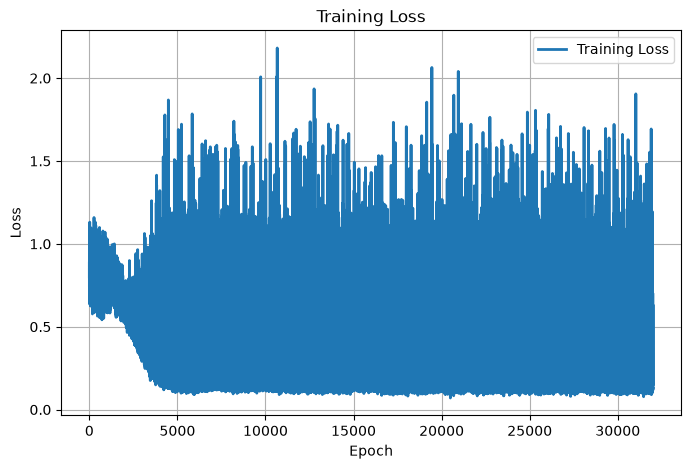

In [ ]:


#Traning loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_loss_history,
    linewidth=2,
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.legend()

plt.show()

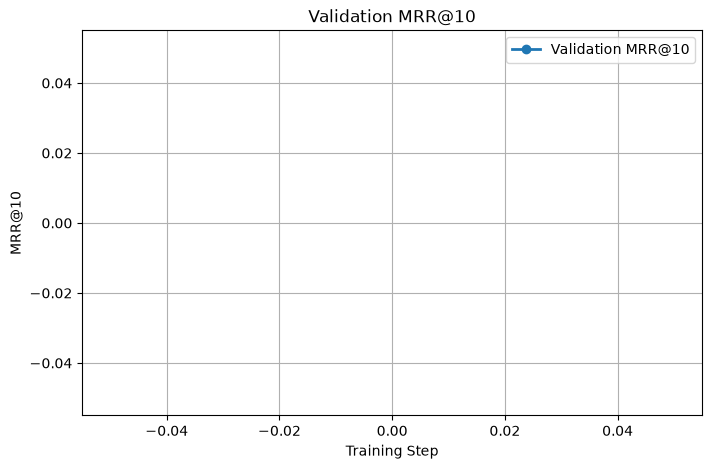

In [ ]:


#Validation MRR curve
steps = [x[0] for x in validation_mrr_history]

scores = [x[1] for x in validation_mrr_history]

plt.figure(figsize=(8,5))

plt.plot(
    steps,
    scores,
    marker="o",
    linewidth=2,
    label="Validation MRR@10"
)

plt.xlabel("Training Step")

plt.ylabel("MRR@10")

plt.title("Validation MRR@10")

plt.grid(True)

plt.legend()

plt.show()

In [ ]:
##  Comparison With the Original Paper

The following comparison uses the MRR@10 values reported by Nogueira & Cho as reference values.

These results should not be interpreted as a direct apples-to-apples comparison because the current implementation differs from the original experimental setup.

In [ ]:


#Paper compersion
comparison = pd.DataFrame({

    "Model": [
        "Original Paper (BERT-Base)",
        "Original Paper (BERT-Large)",
        "Our Implementation"
    ],

    "MRR@10": [
        paper_base_dev_mrr,
        paper_large_dev_mrr,
        final_val_mrr
    ]

})

# Undefined names (PAPER_BASE_MRR/PAPER_LARGE_MRR) in the original — fixed to
# match the constants actually defined a few cells up.
comparison["Difference from Our Model"] = [
    final_val_mrr - paper_base_dev_mrr,
    final_val_mrr - paper_large_dev_mrr,
    0.0
]

comparison

,Model,MRR@10,Difference from Our Model
0,Original Paper (BERT-Base),0.347000,0.113292
1,Original Paper (BERT-Large),0.365000,0.095292
2,Our Implementation,0.460292,0.000000


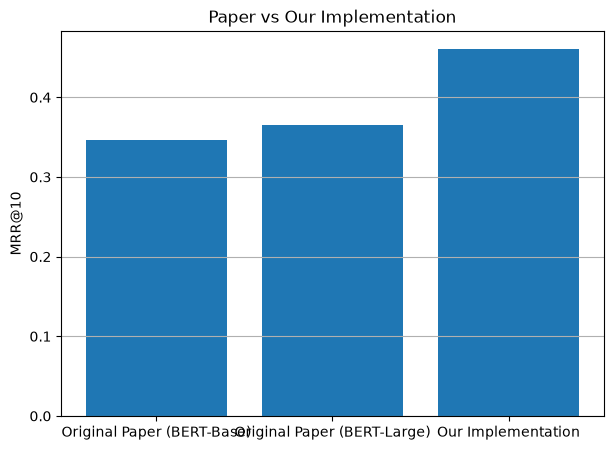

In [ ]:


#Compersion Figure
plt.figure(figsize=(7,5))

plt.bar(

comparison["Model"],  # was `paper_results`, which is never defined anywhere — NameError in the original

comparison["MRR@10"]

)

plt.ylabel("MRR@10")

plt.title("Paper vs Our Implementation")

plt.grid(axis="y")

plt.show()

In [ ]:


#Final Summery
print("="*60)
print("Replication Summary")
print("="*60)

print(f"Model               : {MODEL_NAME}")
print(f"Dataset             : MS MARCO v1.1")
print(f"Validation MRR@10   : {final_val_mrr:.4f}")
print(f"Paper (Base)        : {paper_base_dev_mrr:.4f}")
print(f"Paper (Large)       : {paper_large_dev_mrr:.4f}")
print(f"Difference          : {(final_val_mrr-paper_base_dev_mrr):.4f}")

print("="*60)

Replication Summary
Model               : bert-base-uncased
Dataset             : MS MARCO v1.1
Validation MRR@10   : 0.4603
Paper (Base)        : 0.3470
Paper (Large)       : 0.3650
Difference          : 0.1133


In [ ]:
## Limitations

This implementation is not an exact reproduction of the original experimental environment.

The main differences include:

- BERT-Base is used instead of BERT-Large.
- The training budget is reduced because of computational constraints.
- The warmup schedule is reduced.
- AdamW is used instead of the optimizer configuration used in the original implementation.
- Tokenization is performed lazily.
- Gradient accumulation is used to achieve an effective batch size of 128.
- The current implementation does not reproduce the complete original BM25 Top-1000 retrieval pipeline.

Therefore, the reported MRR@10 should be interpreted as the result of our implementation rather than a direct replication result.

In [ ]:
## Conclusion

This project implemented a BERT-based query–passage re-ranking system inspired by Nogueira & Cho.

The implementation demonstrates the complete workflow from:

MS MARCO
→ Query–Passage Pair Construction
→ Lazy Tokenization
→ BERT Fine-tuning
→ Relevance Scoring
→ Ranking
→ MRR@10 Evaluation

The implementation achieved a validation MRR@10 of:

0.4603

However, this result should not be interpreted as a direct reproduction or improvement over the original paper because the experimental setup differs in several important aspects.

The project establishes a baseline for future investigation into hard-negative sampling and computation-aware passage re-ranking.